# Bloque 2 — $Z_p(s)$, lazo activo y especificaciones de bucle cerrado

Este notebook implementa, para el modelo de Neely & Kim (1986), cóclea de gato:

1. Construcción de $Z_1(s)$–$Z_4(s)$ y combinación en $Z_{p,\text{pasiva}}(s)$ y $Z_p(\gamma,s)$.
2. Reformulación como lazo de realimentación: $G(s)$, $H(s)$ (segundo filtro), $F(s)=-\gamma Z_4(s)H(s)$, $L(s)=G(s)F(s)$.
3. Verificación numérica de que $Z_p(\gamma)=Z_{p,\text{pasiva}}(1+L)$ y de la identidad $S+T=1$.
4. Barrido en $x/L$ de márgenes de ganancia/fase ($M_G$, $M_F$, $\gamma_\text{crit}$) — lazo abierto.
5. Barrido en $x/L$ de especificaciones de lazo cerrado ($M_P$, $\omega_P$, $\omega_b$, cutoff) a partir de $G_{cl}(s)=1/Z_p(\gamma,s)$.
6. Tabla resumen combinada, exportada a CSV para el anexo del docx.

**Antes de ejecutar**: revisa la celda de importación de parámetros (sección 1) y ajusta el import a la ruta real de tu módulo `params_loader` si difiere de la asumida aquí. Si el import falla, el notebook usa automáticamente los valores del CSV corregido como respaldo, para que puedas ejecutarlo igualmente.

In [3]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
import csv

plt.rcParams['figure.dpi'] = 110

## 1. Carga de parámetros

Intenta importar tu `CochlearParams` real del repositorio (`CAT_PARAMS`). Si no está disponible en este entorno, usa un respaldo construido directamente a partir del CSV corregido (`updated_cat_table_params.csv`).

In [4]:
def print_table(rows, cols=None, floatfmt="{:.4g}"):
    """Imprime una lista de dicts como tabla de ancho fijo, sin pandas."""
    if not rows:
        print("(sin filas)")
        return
    cols = cols or list(rows[0].keys())
    def fmt(v):
        if isinstance(v, bool):
            return str(v)
        if isinstance(v, float):
            return floatfmt.format(v)
        return str(v)
    strrows = [[fmt(r.get(c, "")) for c in cols] for r in rows]
    widths = [max(len(c), *(len(sr[i]) for sr in strrows)) for i, c in enumerate(cols)]
    header = "  ".join(c.ljust(w) for c, w in zip(cols, widths))
    print(header)
    print("  ".join("-"*w for w in widths))
    for sr in strrows:
        print("  ".join(v.ljust(w) for v, w in zip(sr, widths)))

def merge_by_key(rows_a, rows_b, key):
    """Une dos listas de dicts por una clave común (equivalente a pd.merge(on=key))."""
    index_b = {r[key]: r for r in rows_b}
    merged = []
    for ra in rows_a:
        rb = index_b.get(ra[key], {})
        row = dict(ra)
        row.update({k: v for k, v in rb.items() if k != key})
        merged.append(row)
    return merged

def save_csv(rows, path, cols=None):
    cols = cols or list(rows[0].keys())
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=cols)
        writer.writeheader()
        for r in rows:
            writer.writerow({c: r.get(c, "") for c in cols})

In [5]:
try:
    from cochleasim.models.params_loader import CAT_PARAMS
    params = CAT_PARAMS
    USE_REPO_PARAMS = True
    print("Usando CAT_PARAMS del repositorio.")
except ImportError:
    USE_REPO_PARAMS = False
    print("No se encontró cochleasim.params_loader — usando parámetros de respaldo (CSV corregido).")

if not USE_REPO_PARAMS:

    def _param(A, b_exp, c=0.0):
        # p(x) = A * exp(b_exp * x) + c  -- misma forma que las filas 'exp' del CSV
        return lambda x: A * np.exp(b_exp * np.asarray(x, dtype=float)) + c

    class _FallbackParams:
        # cgs, x en cm (coincide con el CSV que pegaste)
        k1 = staticmethod(_param(1.10e9, -4))
        c1 = staticmethod(_param(1500, -2, 20))
        m1 = staticmethod(_param(3.00e-3, 0))
        k2 = staticmethod(_param(7.00e6, -4.4))
        c2 = staticmethod(_param(10, -2.2))
        m2 = staticmethod(_param(5.00e-4, 1))
        k3 = staticmethod(_param(1.00e7, -4))
        c3 = staticmethod(_param(2, -0.8))
        k4 = staticmethod(_param(6.15e8, -4))
        c4 = staticmethod(_param(1040, -2))
        gamma = staticmethod(_param(1.0, 0))
        g = staticmethod(_param(1.0, 0))
        b = staticmethod(_param(0.4, 0))
        L = staticmethod(_param(2.5, 0))

    params = _FallbackParams()

# Comprobación rápida (debe coincidir con la fila x/L=0.5 del Bloque 1: fn(Z1)=7910.8 Hz)
x_check = 1.25
fn_Z1_check = (1/(2*np.pi)) * np.sqrt(params.k1(x_check)/params.m1(x_check))
print(f"fn(Z1) en x/L=0.5: {fn_Z1_check:.1f} Hz  (debe ser ~7910.8 Hz)")

Usando CAT_PARAMS del repositorio.
fn(Z1) en x/L=0.5: 7910.8 Hz  (debe ser ~7910.8 Hz)


## 2. Impedancias $Z_1$–$Z_4$ y bloques $G(s)$, $H(s)$, $F(s)$, $L(s)$

`build_transfer_functions(x, params, gamma_val)` construye, para una posición `x` (cm) dada, todos los objetos `TransferFunction` de `python-control` necesarios: $Z_1,\dots,Z_4$, $Z_{p,\text{pasiva}}$, $H(s)$, $G(s)$, $F(s)$, $L(s)$, $Z_p(\gamma)$ y $G_{cl}(s)=1/Z_p(\gamma)$.

Si `gamma_val` no se especifica, se usa `params.gamma(x)` (normalmente 1.0).

In [8]:
s = ct.tf('s')

def build_transfer_functions(x, params, gamma_val=None):
    k1, c1, m1 = params.k1(x), params.c1(x), params.m1(x)
    k2, c2, m2 = params.k2(x), params.c2(x), params.m2(x)
    k3, c3     = params.k3(x), params.c3(x)
    k4, c4     = params.k4(x), params.c4(x)
    g_val, b_val = params.g, params.b
    if gamma_val is None:
        gamma_val = params.gamma(x)

    Z1 = (m1*s**2 + c1*s + k1) / s
    Z2 = (m2*s**2 + c2*s + k2) / s
    Z3 = (c3*s + k3) / s
    Z4 = (c4*s + k4) / s

    Zp_pasiva = (g_val/b_val) * (Z1 + Z2*Z3/(Z2 + Z3))
    H  = g_val * Z2 / (Z2 + Z3)
    G  = 1 / Zp_pasiva
    F  = -gamma_val * Z4 * H
    L  = G * F
    Zp = Zp_pasiva * (1 + L)
    Gcl = 1 / Zp

    return dict(Z1=Z1, Z2=Z2, Z3=Z3, Z4=Z4, G=G, H=H, F=F, L=L,
                Zp_pasiva=Zp_pasiva, Zp=Zp, Gcl=Gcl,
                gamma_val=gamma_val, x=x)

## 3. Verificación numérica de la reducción del lazo

Tres comprobaciones, todas en $x/L=0.5$:

1. $Z_p(\gamma) = Z_{p,\text{pasiva}}(1+L)$ — debe coincidir con el objeto `Zp` construido internamente.
2. $G_{cl}(s) = 1/Z_p(\gamma)$ — coherente por construcción, pero se comprueba igual.
3. $S(j\omega) + T(j\omega) = 1$ para todo $\omega$ — si falla, hay un error en $L(s)$.

In [9]:
def ev(tf_obj, w):
    """Evalúa una TransferFunction de control en s = j*w."""
    return tf_obj(1j*w)

x_test = 1.25  # cm -> x/L = 0.5
w_test = 2*np.pi*1000.0  # 1 kHz

tfs = build_transfer_functions(x_test, params, gamma_val=1.0)

Zp_reconstruido = ev(tfs['Zp_pasiva'], w_test) * (1 + ev(tfs['L'], w_test))
Zp_directo      = ev(tfs['Zp'], w_test)
print("Zp reconstruido (Zp_pasiva*(1+L)):", Zp_reconstruido)
print("Zp directo (build_transfer_functions):", Zp_directo)
print("diferencia relativa:", abs(Zp_reconstruido - Zp_directo) / abs(Zp_directo))

Gcl_check = 1 / Zp_directo
Gcl_directo = ev(tfs['Gcl'], w_test)
print("\nGcl = 1/Zp:", Gcl_check)
print("Gcl (build_transfer_functions):", Gcl_directo)

L_val = ev(tfs['L'], w_test)
S_val = 1/(1 + L_val)
T_val = L_val/(1 + L_val)
print("\nS + T =", S_val + T_val, " (debe ser 1+0j)")

Zp reconstruido (Zp_pasiva*(1+L)): (109.45137709623867-3776.0590531473904j)
Zp directo (build_transfer_functions): (109.45137709618463-3776.0590531474186j)
diferencia relativa: 1.6136039031095342e-14

Gcl = 1/Zp: (7.669710103467878e-06+0.0002646040556051228j)
Gcl (build_transfer_functions): (7.669710103467871e-06+0.0002646040556051228j)

S + T = (1.0000000000000002+1.3877787807814457e-17j)  (debe ser 1+0j)


In [10]:
# Verificación de S+T=1 en TODO el rango de frecuencias, no solo un punto
freqs_check = np.logspace(1, 5, 500)
residuals = []
for w in freqs_check:
    L_val = ev(tfs['L'], w)
    S_val = 1/(1 + L_val)
    T_val = L_val/(1 + L_val)
    residuals.append(abs(S_val + T_val - 1))

print("Residuo máximo |S+T-1| en todo el barrido de frecuencia:", max(residuals))
assert max(residuals) < 1e-9, "La identidad S+T=1 falla -- revisar la construcción de L(s)"
print("OK: identidad S+T=1 verificada.")

Residuo máximo |S+T-1| en todo el barrido de frecuencia: 2.2887833992611187e-16
OK: identidad S+T=1 verificada.


## 4. Barrido en $x/L$: márgenes de ganancia y fase (lazo abierto, $\gamma=1$)

Como $L(\gamma,s)=\gamma L_1(s)$ es lineal en $\gamma$, el margen de ganancia calculado con $\gamma=1$ da directamente $\gamma_\text{crit}=M_{G,\text{lineal}}$ (no hace falta barrer $\gamma$; ver justificación teórica).

In [14]:
xL_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
L_total = params.L  # longitud total de la cóclea (cm)
x_values = xL_values * L_total

rows_margins = []
for xL, x in zip(xL_values, x_values):
    tfs_x = build_transfer_functions(x, params, gamma_val=1.0)
    gm, pm, wcg, wcp = ct.margin(tfs_x['L'])
    gm_dB = 20*np.log10(gm) if (gm not in (0, np.inf)) and gm > 0 else np.nan
    rows_margins.append(dict(
        xL=xL, x_cm=x,
        MG_lineal=gm, MG_dB=gm_dB, MF_deg=pm,
        wg_radps=wcg, wf_radps=wcp,
        gamma_crit=gm  # gamma_nominal=1, así que gamma_crit = MG_lineal
    ))

df_margins = rows_margins  # lista de dicts (antes: pd.DataFrame)
print_table(df_margins)

xL   x_cm  MG_lineal  MG_dB  MF_deg  wg_radps   wf_radps   gamma_crit
---  ----  ---------  -----  ------  ---------  ---------  ----------
0.1  0.25  2.812      8.98   39.38   1.825e+05  1.024e+05  2.812     
0.3  0.75  3.157      9.986  33.79   6.143e+04  2.856e+04  3.157     
0.5  1.25  3.478      10.83  32.64   1.878e+04  7958       3.478     
0.7  1.75  3.583      11.09  35.62   4404       2214       3.583     
0.9  2.25  3.219      10.16  44.78   974        611.5      3.219     


**Nota**: revisa el orden de `wcg`/`wcp` devuelto por tu versión de `python-control` (`ct.margin`) — según la versión, la convención de cuál es la frecuencia de cruce de ganancia y cuál la de fase puede variar. Verifica con `help(ct.margin)` si los valores no cuadran con lo esperado.

### Bode de $L(s)$ con márgenes marcados, para las 5 posiciones

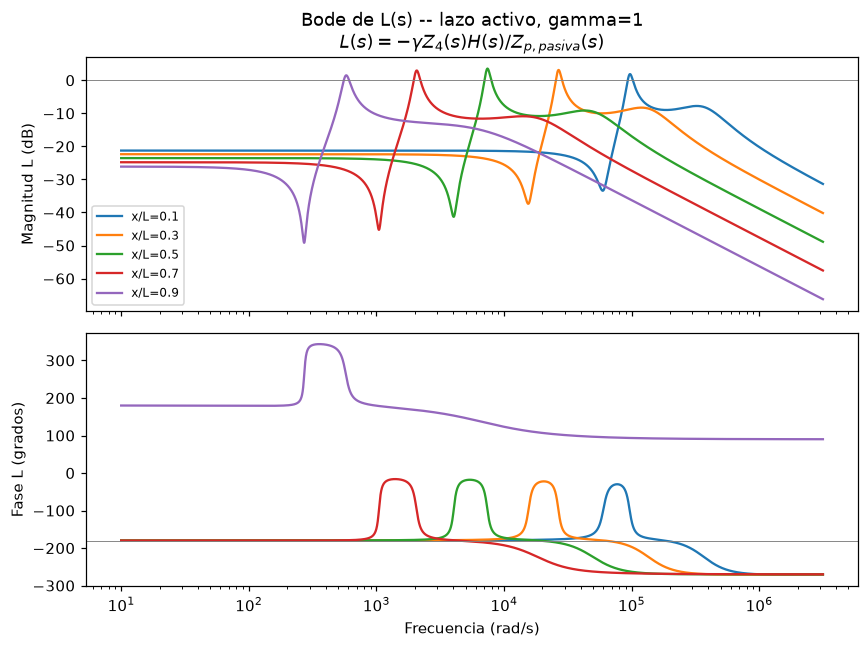

In [15]:
freqs = np.logspace(1, 6.5, 4000)  # rad/s -- mismo rango que en la sección 5

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for xL, x in zip(xL_values, x_values):
    tfs_x = build_transfer_functions(x, params, gamma_val=1.0)
    mag, phase, w = ct.frequency_response(tfs_x['L'], freqs)
    axes[0].semilogx(w, 20*np.log10(np.abs(mag)), label=f"x/L={xL}")
    axes[1].semilogx(w, np.degrees(np.unwrap(np.angle(mag*np.exp(1j*phase)) if False else phase)), label=f"x/L={xL}")

axes[0].axhline(0, color='gray', lw=0.6)
axes[1].axhline(-180, color='gray', lw=0.6)
axes[0].set_ylabel("Magnitud L (dB)")
axes[1].set_ylabel("Fase L (grados)")
axes[1].set_xlabel("Frecuencia (rad/s)")
axes[0].legend(fontsize=8)
axes[0].set_title("Bode de L(s) -- lazo activo, gamma=1\n"
                   r"$L(s) = -\gamma Z_4(s) H(s) / Z_{p,pasiva}(s)$")
plt.tight_layout()
plt.savefig("bode_L_barrido.png", dpi=150)
plt.show()

## 5. Lazo cerrado: $G_{cl}(s)=1/Z_p(\gamma,s)$ — $M_P$, $\omega_P$, $\omega_b$, cutoff, ganancia del amplificador

`closed_loop_specs` extrae, de la respuesta en frecuencia de $G_{cl}(s)$: el pico de resonancia $M_P$ y su frecuencia $\omega_P$, el ancho de banda $\omega_b$ (caída de 3 dB respecto al valor en baja frecuencia) y la pendiente de cutoff (dB/década) al final del barrido.

**Importante**: $M_P$ en valor absoluto **no es comparable entre posiciones** $x/L$, porque la escala de $|Z_{p,\text{pasiva}}|$ cambia con $x$. La magnitud comparable — y la que el propio paper reporta en la Fig. 8 — es la **ganancia del amplificador coclear**, la relación entre el pico activo ($\gamma=1$) y el pico pasivo ($\gamma=0$) en la misma posición:

$$\text{ganancia}_\text{dB} = 20\log_{10}\!\left(\frac{M_P(\gamma=1)}{M_P(\gamma=0)}\right)$$

El paper reporta esta ganancia como 63 dB a 6.4 kHz y 24 dB a 0.4 kHz (Fig. 8) — valor de referencia directo para contrastar.

También se amplía el rango de frecuencias hasta cubrir con margen las posiciones basales (CF hasta 25.6 kHz $\approx$ 1.6$\times10^5$ rad/s).

In [16]:
freqs = np.logspace(1, 6.5, 4000)  # rad/s, hasta ~3x10^6 rad/s -- margen sobre 25.6 kHz (~1.6x10^5 rad/s)

def closed_loop_specs(Gcl_tf, freqs):
    """Mp, wp y ancho de banda medidos ALREDEDOR DEL PICO (Gcl es paso-banda, no paso-bajo:
    Gcl -> 0 tanto en baja como en alta frecuencia, así que no tiene sentido referenciar
    el ancho de banda a un valor en DC)."""
    mag, phase, w = ct.frequency_response(Gcl_tf, freqs)
    mag = np.abs(mag)
    mag_dB = 20*np.log10(mag)

    idx_p = np.argmax(mag)
    Mp = mag[idx_p]
    wp = w[idx_p]
    Mp_dB = mag_dB[idx_p]
    peak_at_boundary = (idx_p == 0) or (idx_p == len(w) - 1)

    target = Mp / np.sqrt(2)  # -3 dB respecto al PICO, no respecto a DC
    idx_below_left  = np.where((w < wp) & (mag < target))[0]
    idx_below_right = np.where((w > wp) & (mag < target))[0]
    w_low  = w[idx_below_left[-1]]  if len(idx_below_left)  else np.nan
    w_high = w[idx_below_right[0]]  if len(idx_below_right) else np.nan
    wb = (w_high - w_low) if (not np.isnan(w_low) and not np.isnan(w_high)) else np.nan
    Q = wp / wb if (wb and not np.isnan(wb)) else np.nan

    # pendiente de cutoff: ajuste lineal log-log en el último 5% del barrido (alta frecuencia)
    n_tail = max(int(0.05*len(w)), 2)
    slope = (mag_dB[-1] - mag_dB[-n_tail]) / (np.log10(w[-1]) - np.log10(w[-n_tail]))

    return dict(Mp=Mp, Mp_dB=Mp_dB, wp_radps=wp, w_low_radps=w_low, w_high_radps=w_high,
                wb_radps=wb, Q_control=Q, cutoff_dBdec=slope, peak_at_boundary=peak_at_boundary,
                _mag=mag, _w=w)  # _mag,_w guardados para reutilizar en la comparación de ganancia

rows_cl = []
for xL, x in zip(xL_values, x_values):
    tfs_activo  = build_transfer_functions(x, params, gamma_val=1.0)
    tfs_pasivo  = build_transfer_functions(x, params, gamma_val=0.0)

    specs_activo = closed_loop_specs(tfs_activo['Gcl'], freqs)
    specs_pasivo = closed_loop_specs(tfs_pasivo['Gcl'], freqs)

    # Ganancia del amplificador tal como la define el paper (Fig. 8): activo vs pasivo
    # EN LA MISMA FRECUENCIA -- la CF del caso activo (wp_activo), no pico contra pico.
    mag_pasivo_en_wp_activo = np.abs(tfs_pasivo['Gcl'](1j*specs_activo['wp_radps']))
    ganancia_dB = 20*np.log10(specs_activo['Mp'] / mag_pasivo_en_wp_activo)

    row = dict(xL=xL, ganancia_amplificador_dB=ganancia_dB,
               Mp_pasivo=specs_pasivo['Mp'])
    row.update({k: v for k, v in specs_activo.items() if not k.startswith('_')})
    rows_cl.append(row)

df_closedloop = rows_cl  # lista de dicts (antes: pd.DataFrame)
if any(r['peak_at_boundary'] for r in df_closedloop):
    print("AVISO: el pico cae en el borde del rango de frecuencias para alguna fila -- ampliar 'freqs'.")
print_table(df_closedloop, cols=['xL', 'ganancia_amplificador_dB', 'Mp_pasivo', 'Mp', 'Mp_dB',
                                  'wp_radps', 'w_low_radps', 'w_high_radps', 'wb_radps',
                                  'Q_control', 'cutoff_dBdec', 'peak_at_boundary'])

xL   ganancia_amplificador_dB  Mp_pasivo  Mp         Mp_dB   wp_radps   w_low_radps  w_high_radps  wb_radps   Q_control  cutoff_dBdec  peak_at_boundary
---  ------------------------  ---------  ---------  ------  ---------  -----------  ------------  ---------  ---------  ------------  ----------------
0.1  3.449                     0.0004294  0.0006051  -64.36  3.204e+05  2.254e+05    4.51e+05      2.256e+05  1.42       -20.65        False           
0.3  3.151                     0.001124   0.001546   -56.22  1.189e+05  8.234e+04    1.7e+05       8.77e+04   1.356      -20.08        False           
0.5  2.748                     0.00278    0.003681   -48.68  4.384e+04  2.914e+04    6.576e+04     3.662e+04  1.197      -20.01        False           
0.7  2.085                     0.006079   0.007556   -42.43  1.617e+04  9528         2.727e+04     1.774e+04  0.9116     -20           False           
0.9  1.27                      0.01081    0.01239    -38.14  5944       2609         1.3

### Bode de $G_{cl}(s)$ con el pico de resonancia marcado, para las 5 posiciones

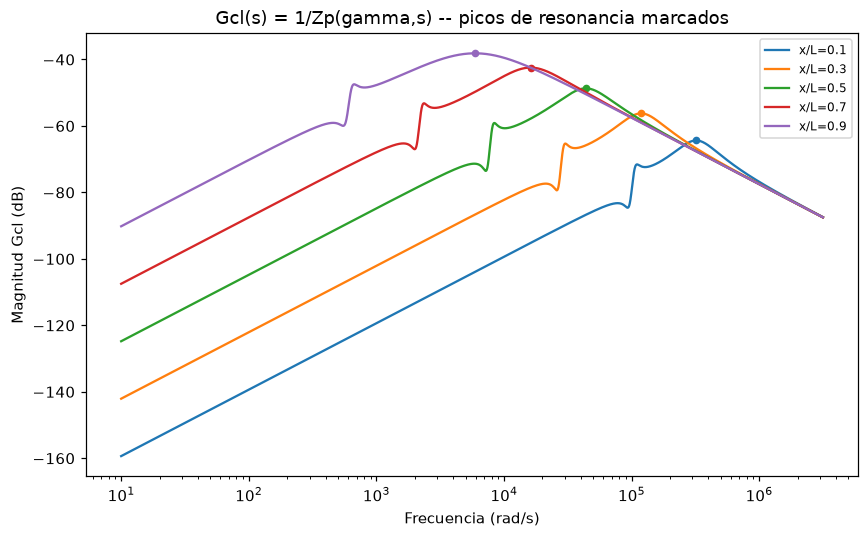

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
for xL, x in zip(xL_values, x_values):
    tfs_x = build_transfer_functions(x, params, gamma_val=1.0)
    mag, phase, w = ct.frequency_response(tfs_x['Gcl'], freqs)
    mag_dB = 20*np.log10(np.abs(mag))
    line, = ax.semilogx(w, mag_dB, label=f"x/L={xL}")
    specs = closed_loop_specs(tfs_x['Gcl'], freqs)
    ax.plot(specs['wp_radps'], specs['Mp_dB'], 'o', color=line.get_color(), ms=4)

ax.set_ylabel("Magnitud Gcl (dB)")
ax.set_xlabel("Frecuencia (rad/s)")
ax.legend(fontsize=8)
ax.set_title("Gcl(s) = 1/Zp(gamma,s) -- picos de resonancia marcados")
plt.tight_layout()
plt.savefig("bode_Gcl_barrido.png", dpi=150)
plt.show()

## 6. Tabla resumen combinada

Une el barrido de lazo abierto (sección 4) con el de lazo cerrado (sección 5) y exporta a CSV para usar directamente en el anexo del `.docx`.

In [18]:
cols_resumen = ['xL', 'x_cm', 'MG_lineal', 'MG_dB', 'MF_deg',
                'gamma_crit', 'ganancia_amplificador_dB',
                'Mp', 'Mp_pasivo', 'Mp_dB', 'wp_radps',
                'w_low_radps', 'w_high_radps', 'wb_radps', 'Q_control',
                'cutoff_dBdec']

df_resumen = merge_by_key(df_margins, df_closedloop, key='xL')
save_csv(df_resumen, "bloque2_resumen_xL.csv", cols=cols_resumen)
print_table(df_resumen, cols=cols_resumen)

xL   x_cm  MG_lineal  MG_dB  MF_deg  gamma_crit  ganancia_amplificador_dB  Mp         Mp_pasivo  Mp_dB   wp_radps   w_low_radps  w_high_radps  wb_radps   Q_control  cutoff_dBdec
---  ----  ---------  -----  ------  ----------  ------------------------  ---------  ---------  ------  ---------  -----------  ------------  ---------  ---------  ------------
0.1  0.25  2.812      8.98   39.38   2.812       3.449                     0.0006051  0.0004294  -64.36  3.204e+05  2.254e+05    4.51e+05      2.256e+05  1.42       -20.65      
0.3  0.75  3.157      9.986  33.79   3.157       3.151                     0.001546   0.001124   -56.22  1.189e+05  8.234e+04    1.7e+05       8.77e+04   1.356      -20.08      
0.5  1.25  3.478      10.83  32.64   3.478       2.748                     0.003681   0.00278    -48.68  4.384e+04  2.914e+04    6.576e+04     3.662e+04  1.197      -20.01      
0.7  1.75  3.583      11.09  35.62   3.583       2.085                     0.007556   0.006079   -42.43  1.617

## 7. Chequeo de las predicciones teóricas

Antes de interpretar nada, comprueba directamente sobre `df_resumen` las predicciones planteadas en la sección teórica:

1. `MG_dB` debería ser mínimo (más cerca de la inestabilidad) en `xL` bajo (base).
2. `Mp` debería ser máximo en `xL` bajo (correlacionado inversamente con `MG_dB`).
3. `wb_radps` debería ser mínimo (pico más estrecho) en `xL` bajo.
4. La identidad $S+T=1$ ya se verificó numéricamente en la sección 3 para $x/L=0.5$; si quieres, repite esa celda para otros `x/L` de la tabla.

In [19]:
def is_monotonic(seq, increasing=True):
    pairs = zip(seq, seq[1:])
    return all(a <= b for a, b in pairs) if increasing else all(a >= b for a, b in pairs)

resumen_ordenado = sorted(df_resumen, key=lambda r: r['xL'])
print_table(resumen_ordenado, cols=cols_resumen)

MG_dB_seq = [r['MG_dB'] for r in resumen_ordenado]
ganancia_seq = [r['ganancia_amplificador_dB'] for r in resumen_ordenado]
wb_seq = [r['wb_radps'] for r in resumen_ordenado]

print("\n--- Chequeo de tendencias ---")
print("MG_dB creciente con xL (esperado, base=peor margen):",
      is_monotonic(MG_dB_seq, increasing=True))
print("ganancia_amplificador_dB decreciente con xL (esperado, base=mayor ganancia activa):",
      is_monotonic(ganancia_seq, increasing=False))
print("wb_radps decreciente con xL (esperado, base=mayor CF=mayor wb en rad/s):",
      is_monotonic(wb_seq, increasing=False))

print("\nReferencia del paper (Fig. 8): ganancia ~63 dB a 6.4 kHz, ~24 dB a 0.4 kHz")

xL   x_cm  MG_lineal  MG_dB  MF_deg  gamma_crit  ganancia_amplificador_dB  Mp         Mp_pasivo  Mp_dB   wp_radps   w_low_radps  w_high_radps  wb_radps   Q_control  cutoff_dBdec
---  ----  ---------  -----  ------  ----------  ------------------------  ---------  ---------  ------  ---------  -----------  ------------  ---------  ---------  ------------
0.1  0.25  2.812      8.98   39.38   2.812       3.449                     0.0006051  0.0004294  -64.36  3.204e+05  2.254e+05    4.51e+05      2.256e+05  1.42       -20.65      
0.3  0.75  3.157      9.986  33.79   3.157       3.151                     0.001546   0.001124   -56.22  1.189e+05  8.234e+04    1.7e+05       8.77e+04   1.356      -20.08      
0.5  1.25  3.478      10.83  32.64   3.478       2.748                     0.003681   0.00278    -48.68  4.384e+04  2.914e+04    6.576e+04     3.662e+04  1.197      -20.01      
0.7  1.75  3.583      11.09  35.62   3.583       2.085                     0.007556   0.006079   -42.43  1.617

## 8. (Opcional) Cruce de validación con el pico de $|\xi_b(x)|$ ya simulado

Si tienes ya el resultado de `solve_pressure` / `xi_b(x)` para alguna de estas frecuencias características, puedes comparar aquí el $M_P$ de esta sección con la altura del "tip" de la curva de sintonía ya simulada — deberían coincidir salvo un factor de escala constante ($1/(i\omega b)$, ver desarrollo teórico). Completa la celda siguiente con tu función de simulación real.

In [20]:
# Plantilla -- ajusta a tu API real de simulación
#
# from cochleasim.models.cochlear_model import solve_pressure
#
# for xL, x in zip(xL_values, x_values):
#     specs = closed_loop_specs(build_transfer_functions(x, params, gamma_val=1.0)['Gcl'], freqs)
#     omega_p_hz = specs['wp_radps'] / (2*np.pi)
#     Pd, xi_b, xi_c = solve_pressure(omega_p_hz, params)  # ajustar firma real
#     pico_simulado = np.max(np.abs(xi_b))
#     print(f"x/L={xL}: Mp (control)={specs['Mp']:.3g}  pico |xi_b| simulado={pico_simulado:.3g}")
pass